Lab Module 4 - Hair Care Product - Samuel Scott

# Problem 14.2 - Hair Care Product - Uplift Modeling
This problem uses the data set in _Hair-Care-Product.csv_, courtesy of SAS. In this hypothetical case, a promotion for a hair care product was sent to some members of a buyers club.  Purchases were then recorded for both the members who got the promotion and those who did not.

In [1]:
!python --version

Python 3.13.5


In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pylab as plt
import mlba

%matplotlib inline

In [3]:
data = mlba.load_data('Hair-Care-Product.csv')
data.head()

,Purchase,Age,Hair Color,U.S. Region,Validation,Promotion_ord,Gender_ord,Residence_ord
0,0,25,Black,Southwest,1,1,0,1
1,0,30,Black,Northwest,1,0,0,1
2,0,45,Red,Northeast,1,0,0,0
3,0,35,Blond,Southwest,0,0,0,1
4,0,33,Brown,Southwest,0,1,0,1


__13.4.a__ 
What is the purchase propensity 

__13.4.a.i__
among those who received the promotion? 

> The purchase propensity among those who received the promotion
= (Number of purchases made) / (Total Number of Records)

The `Promotion_ord` column has a 1 for members that received a promotion. The `Purchase` column has a 1 for members that purchased a product after the promotion. By multiplying the two columns we therefore get a 1 for all members that received a promotion and made a purchase and a 0 otherwise. 

In [11]:
number_purchases_made_after_promotion = sum(data['Purchase'] * data['Promotion_ord']) #there are 80 times in this data set when both data['Purchase']
print(f'Number of purchases made after promotion: {number_purchases_made_after_promotion}')

number_of_members_who_got_promotion = sum(data['Promotion_ord'])
print(f'Number of members who got promotion: {number_of_members_who_got_promotion}')

purchase_propensity = number_purchases_made_after_promotion / number_of_members_who_got_promotion
print(f'Purchase propensity: {purchase_propensity:.4%}')

Promotion_ord
0    5024
1    4976
Name: count, dtype: int64
Number of purchases made after promotion: 80
Number of members who got promotion: 4976
Purchase propensity: 1.6077%


In [12]:
number_of_purchases_made_without_promotion = sum(data['Purchase'] * (1-data['Promotion_ord']))
print(f'Number of purchases made without promotion: {number_of_purchases_made_without_promotion}')

number_of_members_who_did_not_get_promotion = sum(1-data['Promotion_ord'])
print(f'Number of members who did not get promotion: {number_of_members_who_did_not_get_promotion}')

purchase_propensity_without_promotion = number_of_purchases_made_without_promotion / number_of_members_who_did_not_get_promotion
print(f'Purchase propensity without promotion: {purchase_propensity_without_promotion:.4%}')

Number of purchases made without promotion: 32
Number of members who did not get promotion: 5024
Purchase propensity without promotion: 0.6369%


In [13]:
data['Hair Color'] = data['Hair Color'].astype('category')
data['U.S. Region'] = data['U.S. Region'].astype('category')

data = pd.get_dummies(data)
data.head()

,Purchase,Age,Validation,Promotion_ord,Gender_ord,Residence_ord,Hair Color_Black,Hair Color_Blond,Hair Color_Brown,Hair Color_Red,U.S. Region_Northeast,U.S. Region_Northwest,U.S. Region_Southeast,U.S. Region_Southwest
0,0,25,1,1,0,1,True,False,False,False,False,False,False,True
1,0,30,1,0,0,1,True,False,False,False,False,True,False,False
2,0,45,1,0,0,0,False,False,False,True,True,False,False,False
3,0,35,0,0,0,1,False,True,False,False,False,False,False,True
4,0,33,0,1,0,1,False,False,True,False,False,False,False,True


In [14]:
train, holdout = train_test_split(data, test_size=0.4, random_state=1)

__13.4.b.i__
Uplift using a Random Forest.

In [15]:
rf = RandomForestClassifier(n_estimators=100, random_state=1)
rf.fit(train.drop(columns=['Purchase']), train['Purchase'])

pred = rf.predict(holdout.drop(columns=['Purchase']))

mlba.classificationSummary(y_true=holdout['Purchase'], y_pred=pred)

Confusion Matrix (Accuracy 0.9835)

       Prediction
Actual    0    1
     0 3934   14
     1   52    0


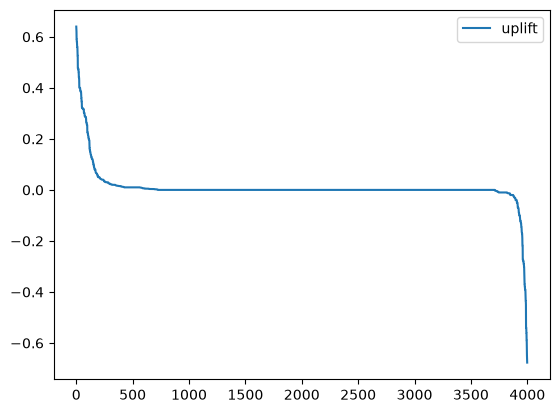

In [16]:
uplift_df = holdout.drop(columns=['Purchase']).copy()

uplift_df['Promotion_ord'] = 1
pred_treatment = rf.predict_proba(uplift_df)
uplift_df['Promotion_ord'] = 0
pred_control = rf.predict_proba(uplift_df)

uplift_result_rf = pd.DataFrame({'probMessage':pred_treatment[:,1], 'probNoMessage': pred_control[:, 1],
                                 'uplift': pred_treatment[:,1] - pred_control[:,1]}, index=uplift_df.index)
uplift_result_rf = uplift_result_rf.sort_values(by=['uplift'], ascending=False)
uplift_result_rf.reset_index().plot(x=None, y='uplift')

plt.show()

__13.4.b.ii__
Uplift using $k$-NN.

In [17]:
knn = KNeighborsClassifier(n_neighbors=11)
knn.fit(train.drop(columns=['Purchase']), train['Purchase'])

pred = knn.predict(holdout.drop(columns=['Purchase']))
mlba.classificationSummary(y_true=holdout['Purchase'], y_pred=pred)

Confusion Matrix (Accuracy 0.9870)

       Prediction
Actual    0    1
     0 3948    0
     1   52    0


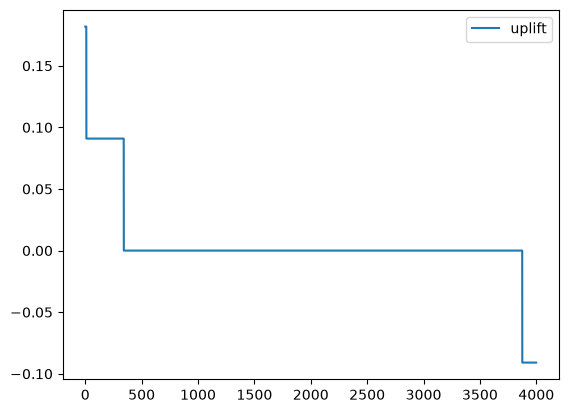

In [18]:
uplift_df = holdout.drop(columns=["Purchase"]).copy()

uplift_df["Promotion_ord"] = 1
pred_treatment = knn.predict_proba(uplift_df)
uplift_df["Promotion_ord"] = 0
pred_control = knn.predict_proba(uplift_df)

uplift_result_knn = pd.DataFrame(
    {
        "probMessage": pred_treatment[:, 1],
        "probNoMessage": pred_control[:, 1],
        "uplift": pred_treatment[:, 1] - pred_control[:, 1],
    },
    index=uplift_df.index,
)

uplift_result_knn = uplift_result_knn.sort_values(by=["uplift"], ascending=False)
uplift_result_knn.reset_index().plot(x=None, y="uplift")

plt.show()

 __13.4.c__ Report the two models' recommendations for the first three members.

In [ ]:
uplift_result_rf.head(3)

In [ ]:
uplift_result_knn.head(3)